In [2]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
#color_list = sns.color_palette() + sns.color_palette("Set2") + sns.color_palette("Set3")
color_list = (
    sns.color_palette("colorblind", 10) +
    sns.color_palette("Dark2", 8) +
    sns.color_palette("tab20", 20)
)

dim = 3
save_dir = f'data/{dim}d/rpa'

# single run with and without refinent (maybe also compare with tprc method)
# rest with more runs

Starting serial run at: 2026-06-03 17:14:28.648456


In [2]:
import numpy as np
import matplotlib.pyplot as plt

square = LATTICE(dim=2, tp=0.)
nk = 200

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

# --- Compute A(k,0) ---
eta = 0.01  # broadening, tune to ~pi*T or Im Sigma(0)
mu = get_mu(e_k=square.e_k, n_goal=0.9, beta=1/1)
Ak0 = (1/np.pi) * eta / (eta**2 + (eps - mu)**2)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: dispersion + bare FS ---
ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

# --- Plot 2: A(k,0) ---
ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
#ax.contour(kx, ky, eps, levels=[mu], colors='cyan', linewidths=1, linestyles='--')
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

AttributeError: 'LATTICE' object has no attribute 'k_vecs_fine'

-0.2 [-0.8399053199761002, -0.6919498838006279, -0.47658709313787545]
0.0 [-0.4269061742971663, -0.1801275395682463, 0.0]
0.2 [-0.11153337844605017, 0.20753242312156925, 0.47658709313792585]


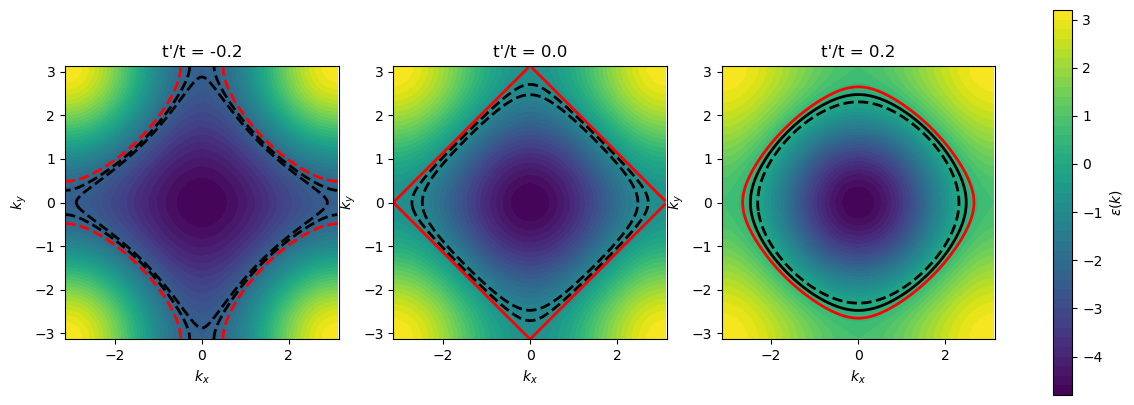

In [39]:
import numpy as np
import matplotlib.pyplot as plt

tp_list = [-0.2, 0., 0.2]

nk = 200

k_mesh, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.01
n_list = [0.8, 0.9, 1.]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tp in zip(axes, tp_list):
    square = LATTICE(dim=2, tp=tp)
    
    square.get_e_k(nk)
    eps = square.e_k.data[:, 0, 0].real
    eps = eps.reshape(nk, nk)
    eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

    cf = ax.contourf(kx, ky, eps, levels=50)

    mu_list = [get_mu(e_k=square.e_k, n_goal=n, beta=1/T) for n in n_list]
    print(tp, mu_list)
    ax.contour(kx, ky, eps, levels=mu_list[:-1], colors='black', linewidths=2)
    ax.contour(kx, ky, eps, levels=[mu_list[-1]], colors='red', linewidths=2)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_title(f"t'/t = {tp}")
    ax.set_aspect('equal')

fig.colorbar(cf, ax=axes, label=r'$\varepsilon(k)$')
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


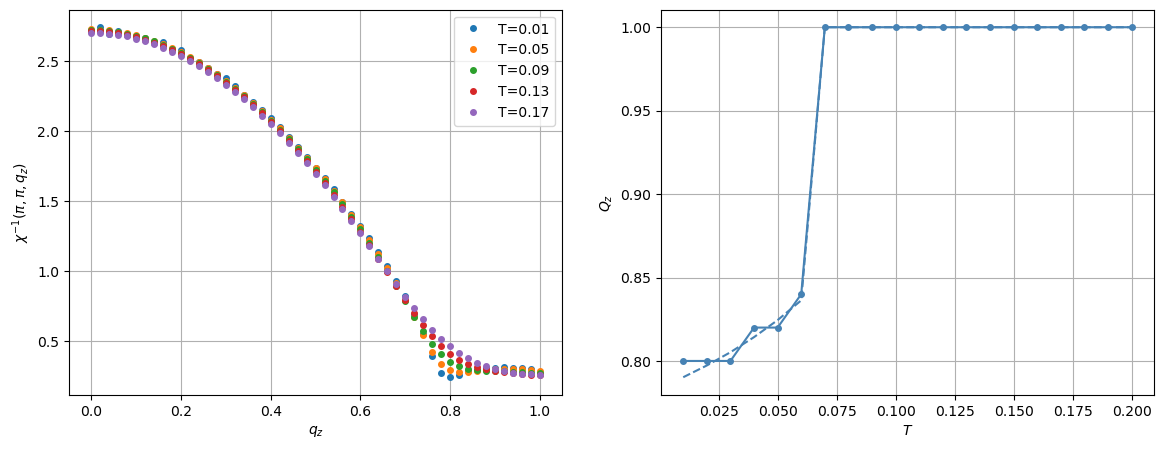

In [14]:
n = 0.865
T_list = np.linspace(0.01, 0.2, 20)
U = 3

nk = 100
lat = LATTICE(tp=0.2)
lat.get_bz(nk, ibz=True)
lat.get_e_k()

refine_ratio = 2
nk_fine = int(nk*refine_ratio)
lat.get_bz(nk_fine, ibz=True, fine=True)
lat.get_e_k(fine=True)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z$')

q_path = ([1,1,0],[1,1,1])
qz_grid = get_grid_from_path(q_path, lat.k_vecs)[:,-1]
step = qz_grid[1] - qz_grid[0]
Qz = []
Qz_ref = []
for i, T in enumerate(T_list):
    mu = get_mu(lat.e_k_fine, n, 1/T, ibz_w_k=lat.ibz_w_k_fine)

    Q, _, invchi0_grid = get_invchi0_min(lat, mu, 1/T, nk, q_path, 'lindhard')
    Q_ref, invchi0_Q = refine_min(lat, mu, 1/T, nk, Q, q_path, refine_ratio=refine_ratio)
    #fit_out, grid_pts = fit_invxi(lat, mu, 1/T, U, nk_fine, Q_ref)
    
    Qz.append(Q[-1])
    Qz_ref.append(Q_ref[-1])
    if i%4 == 0:
        ax[0].plot(qz_grid, invchi0_grid-U, 'o', markersize=4, label=f'T={T:.2f}')

        #par, _ = fit_out
        #color = ax[0].lines[-1].get_color()
        #q_grid_fitted, invchi_grid_fitted = grid_pts
        #OZ_curve = [1/OZ(np.pi*(qz - Q_ref[-1]), *par) for qz in q_grid_fitted[:,-1]]
        #ax[0].plot(q_grid_fitted[:,-1], invchi_grid_fitted, color=color)
        #ax[0].plot(q_grid_fitted[:,-1], OZ_curve, '--', color='black', linewidth=0.7)
        #ax[0].plot(Q_ref[-1], invchi0_Q-U, 'x', markersize=4, color='black')
    
    print(f'\r{i}')

ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[1].plot(T_list, Qz_ref, '--', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-27 23:57:22.786775
Starting serial run at: 2026-05-27 23:57:22.797123
Starting serial run at: 2026-05-27 23:57:22.799331
Starting serial run at: 2026-05-27 23:57:22.817156
Starting serial run at: 2026-05-27 23:57:22.851030
Starting serial run at: 2026-05-27 23:57:22.903646


90  finito
92  finito


[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed: 19.4min remaining: 38.9min


100  finito


[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed: 20.7min remaining: 20.7min


98  finito


[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed: 20.9min remaining: 10.5min


96  finito
94  finito


[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed: 23.5min finished


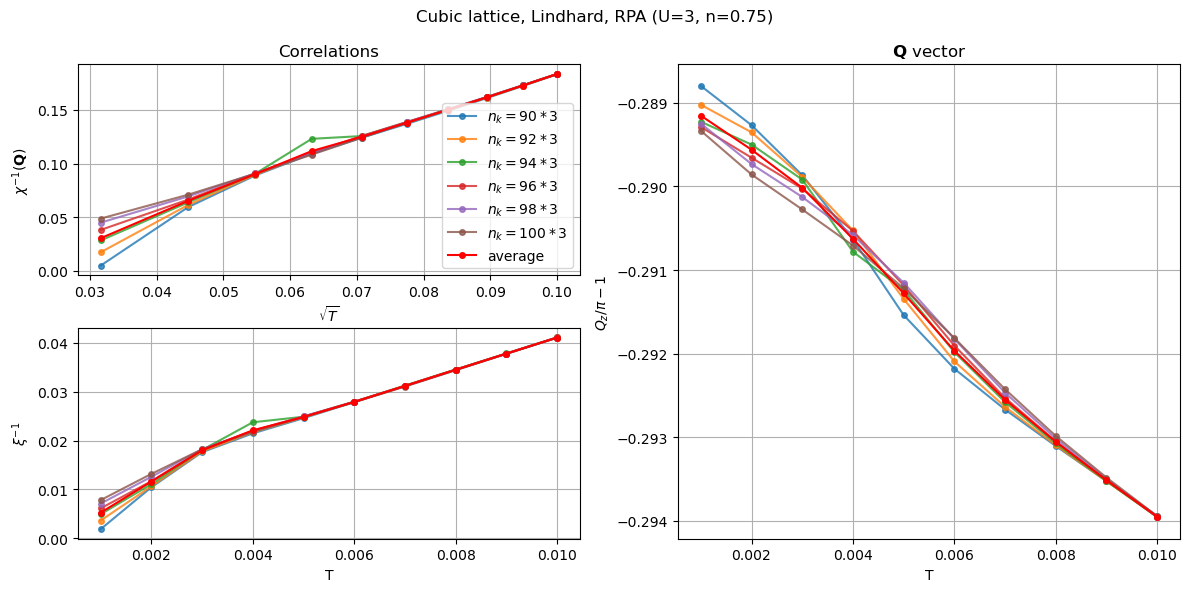

In [ ]:
U = 3
n = 0.75
T_list = np.linspace(0.001, 0.01, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard, RPA (U={U}, n={n})'

nk_list = list(range(90, 101, 2))
refine_ratio = 3
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'lindhard', 'q_path': ([1,1,0],[1,1,1]),
               'refine_ratio': refine_ratio, 'get_xi': True} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['invxi'] = sum([results['invxi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1),
                        title=title, label=f'$n_k={nk}*{refine_ratio}$', figure=fig, alpha=0.8)
    
fig, _ = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), fit=False, x_exp=(0.5,1),
                    title=title, label=f'average', figure=fig, color='red')

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.74, 0.76, 5)
T_list = np.linspace(0.005, 0.015, 15)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 100
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 
               'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 3, 'get_xi': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1), fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    #_, axs = fig
    #color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    #axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


KeyboardInterrupt: 

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed: 36.9min remaining: 55.3min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed: 37.0min remaining: 24.6min
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed: 37.1min finished


n = 0.75 :
 chi: gamma = 0.711, Tc = -0.016, xi: nu = 1.128, Tc = -0.024
n = 0.755 :
 chi: gamma = 0.717, Tc = -0.007, xi: nu = 1.081, Tc = -0.016
n = 0.76 :
 chi: gamma = 0.680, Tc = 0.000, xi: nu = 0.989, Tc = -0.006
n = 0.765 :
 chi: gamma = 0.729, Tc = 0.004, xi: nu = 0.897, Tc = -0.000
n = 0.77 :
 chi: gamma = 0.715, Tc = 0.012, xi: nu = 0.745, Tc = 0.002


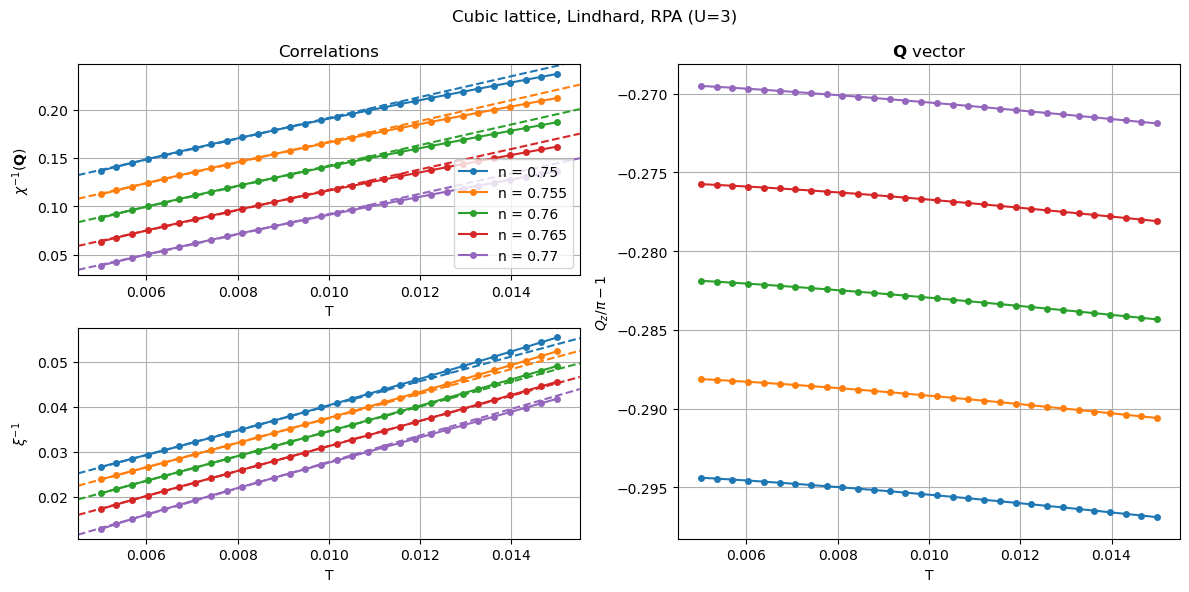

In [ ]:
U = 3
n_list = np.linspace(0.75, 0.77, 5)
T_list = np.linspace(0.005, 0.015, 30)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 100
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'tp': 0.01,
               'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 3, 'get_xi': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    #_, axs = fig
    #color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    #axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-06-03 15:05:57.431435
Starting serial run at: 2026-06-03 15:05:57.437035
Starting serial run at: 2026-06-03 15:05:57.440497
Starting serial run at: 2026-06-03 15:05:57.475027


Starting serial run at: 2026-06-03 15:05:57.644883
Starting serial run at: 2026-06-03 15:05:57.656686
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed: 21.8min remaining: 43.6min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed: 22.2min remaining: 22.2min
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed: 22.4min remaining: 11.2min
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed: 22.5min finished


n = 0.8865 :
 chi: gamma = 1.450, Tc = -0.031
n = 0.8865999999999999 :
 chi: gamma = 1.469, Tc = -0.027
n = 0.8866999999999999 :
 chi: gamma = 1.487, Tc = -0.023
n = 0.8868 :
 chi: gamma = 1.507, Tc = -0.017
n = 0.8869 :
 chi: gamma = 1.527, Tc = -0.009
n = 0.887 :
 chi: gamma = 1.547, Tc = 0.009


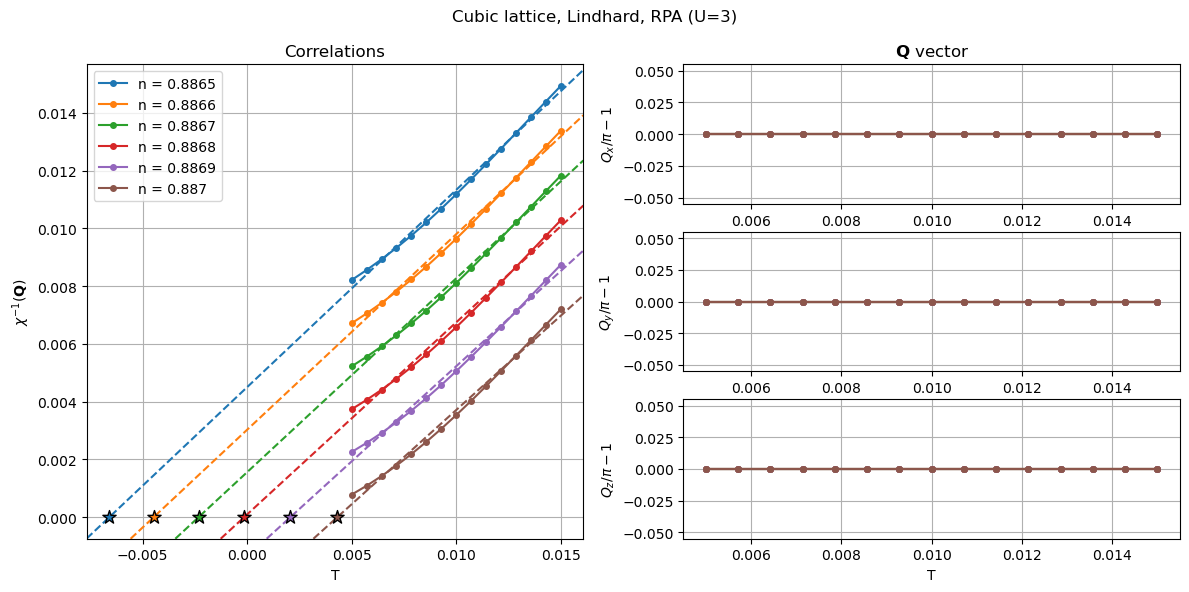

In [11]:
U = 3
n_list = np.linspace(0.8865, 0.887, 6)
T_list = np.linspace(0.005, 0.015, 15) #np.concatenate([np.linspace(0.01, 0.02, 15), np.linspace(0.02, 0.1, 15)])

par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 200
#sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'matsubara', 'tp': 0.17,
#               'niw': 64, 'refine_ratio': 2} for par_dict in par_list]
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'tp': 0.175,
               'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 2} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    #Tc_xi = results['fitxi']['Xc']
    #nu = results['fitxi']['b']
    #print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.5g}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-06-03 19:16:31.709833
Starting serial run at: 2026-06-03 19:16:31.709836
Starting serial run at: 2026-06-03 19:16:31.709836
Starting serial run at: 2026-06-03 19:16:31.709836
Starting serial run at: 2026-06-03 19:16:31.741118
Starting serial run at: 2026-06-03 19:16:31.752014
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed: 34.2min remaining: 68.4min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed: 34.3min remaining: 34.3min
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed: 37.9min remaining: 19.0min
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed: 41.7min finished


n = 0.8865 :
 chi: gamma = 1.053, Tc = -0.008
n = 0.8866999999999999 :
 chi: gamma = 1.060, Tc = -0.007
n = 0.8868999999999999 :
 chi: gamma = 2.757, Tc = -0.176
n = 0.8871 :
 chi: gamma = 1.483, Tc = -0.028
n = 0.8873 :
 chi: gamma = 1.368, Tc = -0.009
n = 0.8875 :
 chi: gamma = 1.502, Tc = 0.011


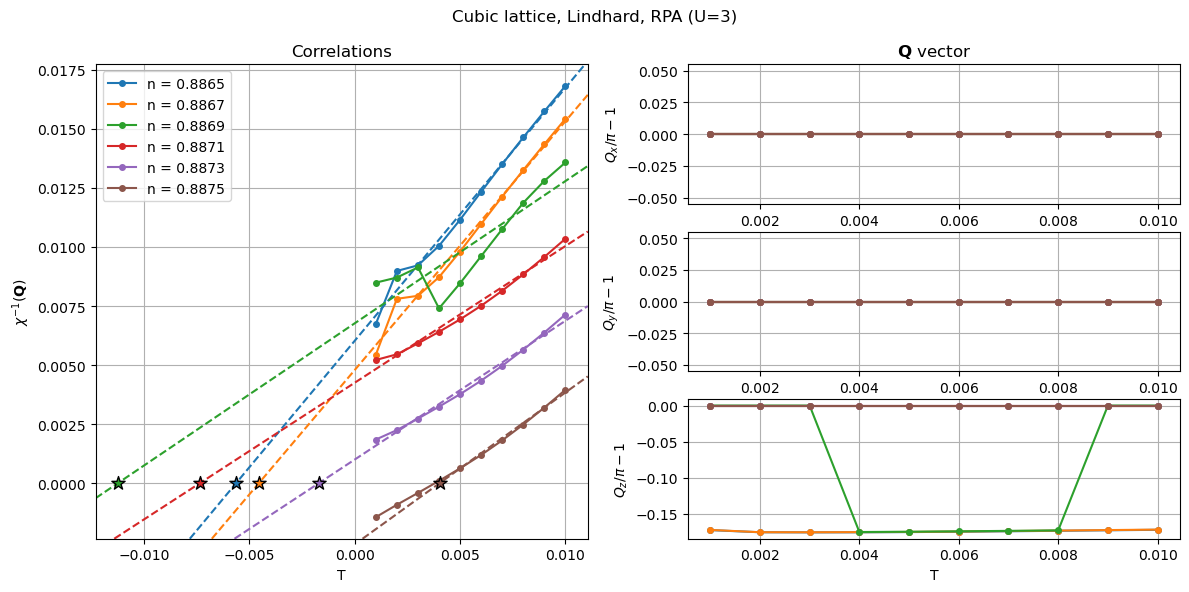

In [ ]:
U = 3
n_list = np.linspace(0.8865, 0.8875, 6)
T_list = np.concatenate([np.linspace(0.005, 0.015, 15), np.linspace(0.015, 0.1, 15)])

par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 300
#sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'matsubara', 'tp': 0.18,
#               'niw': 128, 'refine_ratio': 2} for par_dict in par_list]
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'tp': 0.172,
               'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 4./3, 'refine': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    #Tc_xi = results['fitxi']['Xc']
    #nu = results['fitxi']['b']
    #print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.5g}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

n = 0.8865 :
 chi: gamma = 1.053, Tc = -0.008
n = 0.8866999999999999 :
 chi: gamma = 1.060, Tc = -0.007
n = 0.8868999999999999 :
 chi: gamma = 2.757, Tc = -0.176
n = 0.8871 :
 chi: gamma = 1.483, Tc = -0.028
n = 0.8873 :
 chi: gamma = 1.368, Tc = -0.009
n = 0.8875 :
 chi: gamma = 1.502, Tc = 0.011


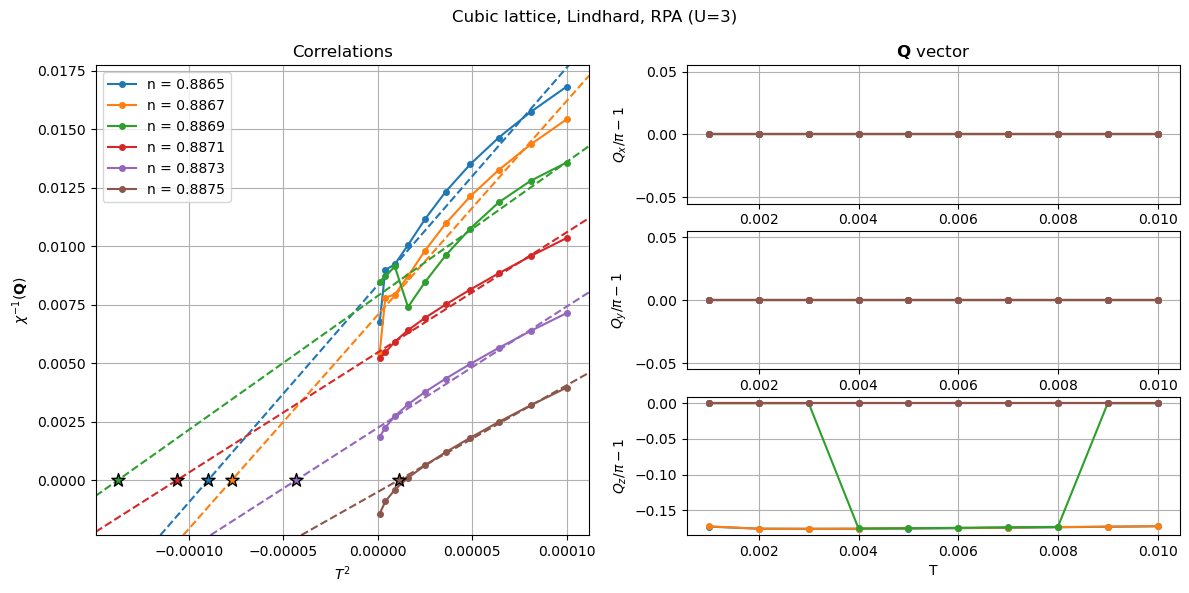

In [13]:
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    #Tc_xi = results['fitxi']['Xc']
    #nu = results['fitxi']['b']
    #print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(2,1), fit=True,
                        title=title, label=f'n = {n:.5g}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-08 08:47:09.601029
Starting serial run at: 2026-05-08 08:47:09.602177
Starting serial run at: 2026-05-08 08:47:09.609273
Starting serial run at: 2026-05-08 08:47:09.638499
Starting serial run at: 2026-05-08 08:47:09.638526
Starting serial run at: 2026-05-08 08:47:09.649912
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:    2.5s remaining:    5.0s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    2.5s remaining:    2.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:    2.6s remaining:    1.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    2.6s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   33.5s remaining:  1.1min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   34.1s remaining:   34.1s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   34.2s remaining:   17.1s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   34.5s finished

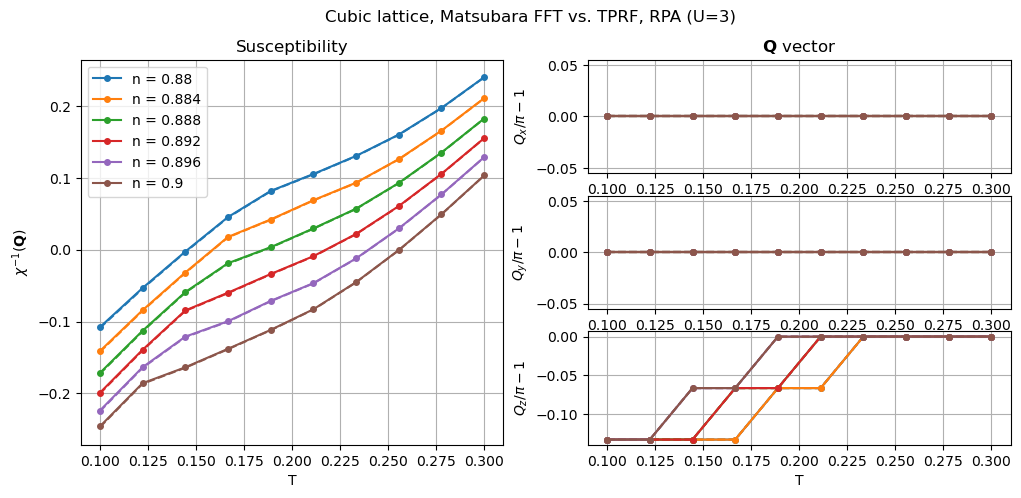

In [ ]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 10)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. TPRF, RPA (U={U})'

nk = 30
niw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_fft', 'niw': niw, 'niw_extr': True} for par_dict in par_list]
results_list_fft = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_tprf', 'niw': niw} for par_dict in par_list]
results_list_tprf = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_fft, res_tprf in zip(results_list_fft, results_list_tprf):
    n = res_fft['par_list'][0]['n']
    fig, fit = pcut_chi(res_fft, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_tprf, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   24.5s remaining:   49.1s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   24.6s remaining:   24.6s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   24.6s remaining:   12.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   24.8s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:    3.3s remaining:    6.6s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    3.5s remaining:    3.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:    3.6s remaining:    1.8s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    3.9s finished


n = 0.88 : exp_mats = 0.00459947385692727, exp_lindh = 0.6090094017234252
n = 0.884 : exp_mats = 1.5042907976424826, exp_lindh = 1.4066120748489646
n = 0.888 : exp_mats = 3.0881358593315054, exp_lindh = 3.1278245090513668
n = 0.892 : exp_mats = 2.557290557810163, exp_lindh = 2.5585820870013025
n = 0.896 : exp_mats = 2.1905518747293957, exp_lindh = 2.191427703925661
n = 0.9 : exp_mats = 1.9623109816835178, exp_lindh = 1.962990711041491


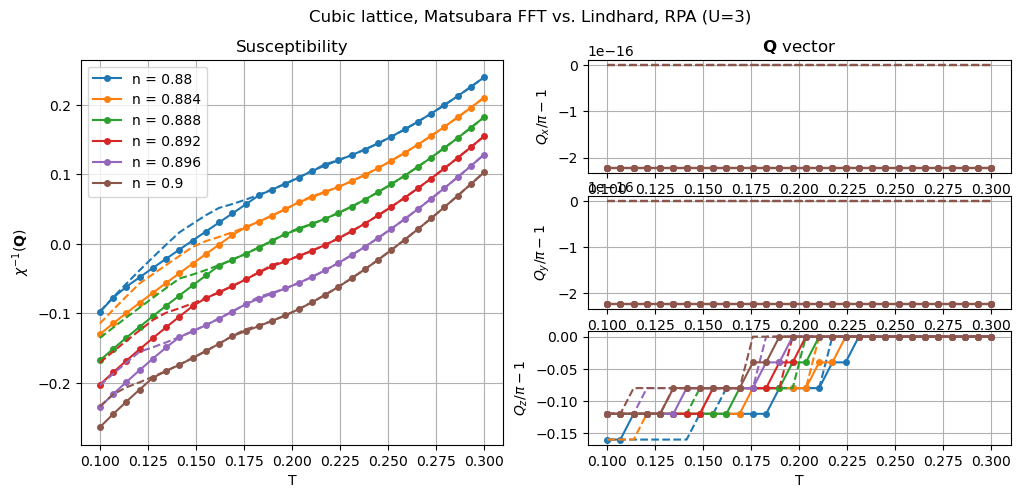

In [ ]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 30)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U})'

nk = 50
niw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'niw': niw, 'niw_extr': True} for par_dict in par_list]
results_list_mats = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
results_list_lindh = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_mats, res_lindh in zip(results_list_mats, results_list_lindh):
    n = res_mats['par_list'][0]['n']
    print(f"n = {n} : exp_mats = {res_mats['gamma']}, exp_lindh = {res_lindh['gamma']}")
    fig, fit = pcut_chi(res_mats, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_lindh, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Starting serial run at: 2026-05-19 22:33:56.803586
Starting serial run at: 2026-05-19 22:33:56.849625
Starting serial run at: 2026-05-19 22:33:56.850393
Starting serial run at: 2026-05-19 22:33:56.852011
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:    2.0s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    2.4s remaining:    2.4s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    4.7s finished


Completed 15 jobs in 7.20 seconds | U=3.000, T=0.050, n=0.850
Completed 15 jobs in 1.43 seconds | U=3.000, T=0.050, n=0.850


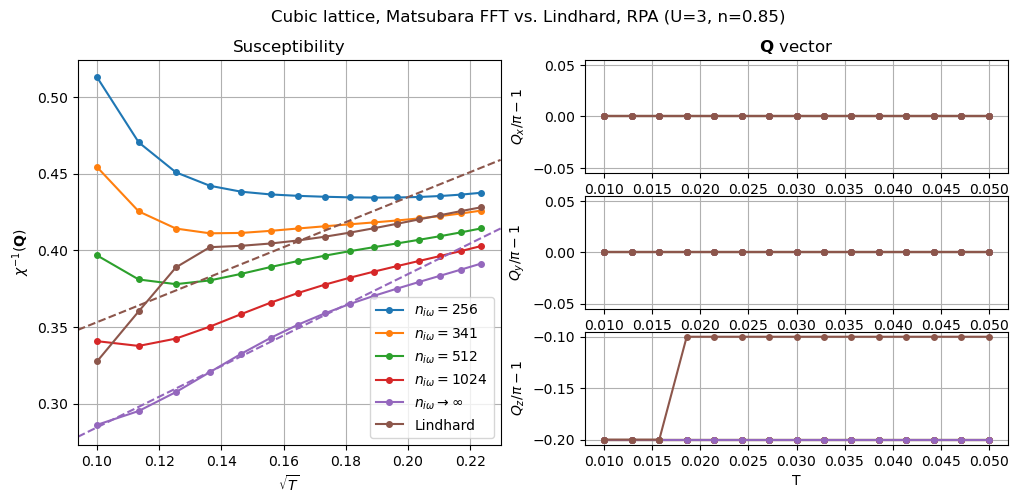

In [2]:
U = 3
n = 0.85
T_list = np.linspace(0.01, 0.05, 15)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U}, n={n})'

nk = 20
niw_list = 1024//np.array([4,3,2,1])

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'niw': niw, 'niw_extr': False, 'tp': 0.2, 'refine': False} for niw in niw_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=4)

fig = None
for results in results_list:
    niw = results['niw']
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=False, x_exp=0.5, title=title, label=f'$n_{{i\omega}}={niw}$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, niw=niw_list[-1], niw_extr=True, tp=0.2, refine=False)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label=r'$n_{{i\omega}}\to\infty$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, method='lindhard', q_path=([1,1,0], [1,1,1]), tp=0.2, refine=False)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label='Lindhard', figure=fig)

plt.show()

In [14]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 15)

nk = 82
file = f'{save_dir}/nTdiag_U3'
if os.path.exists(file):
    results = HDFread_list(file, ['Xc'])
    n_old = [par_list[0]['n'] for par_list in results['par_list']]
    Tc_old = [x[0] for x in results['Xc']]
    Tc = np.interp(n_list, n_old, Tc_old)
else:
    print(f'file {file} does not exist!')

par_list = []
for i, n in enumerate(n_list):
    par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1]),
               'fit': True, 'fit_type': [critical1, critical2], 'refine_ratio': 2} for par_dict in par_list]
results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  2.2min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  2.4min


Starting serial run at: 2026-05-20 15:52:05.917237


Starting serial run at: 2026-05-20 15:52:08.894968


Starting serial run at: 2026-05-20 15:52:09.437204


Starting serial run at: 2026-05-20 15:52:12.669580


Starting serial run at: 2026-05-20 15:52:15.988919


Starting serial run at: 2026-05-20 15:52:19.460195
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed:  6.5min
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed:  6.6min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 10.5min remaining:  2.8min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 10.6min remaining:   57.8s
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 11.9min finished


[-1.0494964431761837, -1.0053180014868326, -0.9588398929558146, -0.9127511719370774, -0.8686506995012256, -0.82189252521188, -0.7762624908615554, -0.73112602696222, -0.6852721375142886, -0.6396527989636209, -0.5939931612873681, -0.5483220077731717, -0.502637654367852, -0.4569370388897518, -0.41120973384587084, -0.3654541337223653, -0.3198119217086048, -0.27418628631139735, -0.2285448128599565, -0.18287798050518103, -0.13718449633023985, -0.09146966811562157, -0.04573895644454949, 0.0]
[-1.0495921157395696, -1.0051849427619701, -0.9588378550749725, -0.9127171438332049, -0.8686568184074553, -0.821922641994062, -0.7762962588197556, -0.7311046690424544, -0.6852745635671387, -0.6396526999461565, -0.5939930593511061, -0.5483218845658707, -0.5026375033488646, -0.45693684612770463, -0.4112075468184825, -0.36545414517360547, -0.3198116480660971, -0.27418610784238423, -0.22854474432518646, -0.18287798077522005, -0.1371845962067406, -0.09146978286085078, -0.04573902842120735, 0.0]


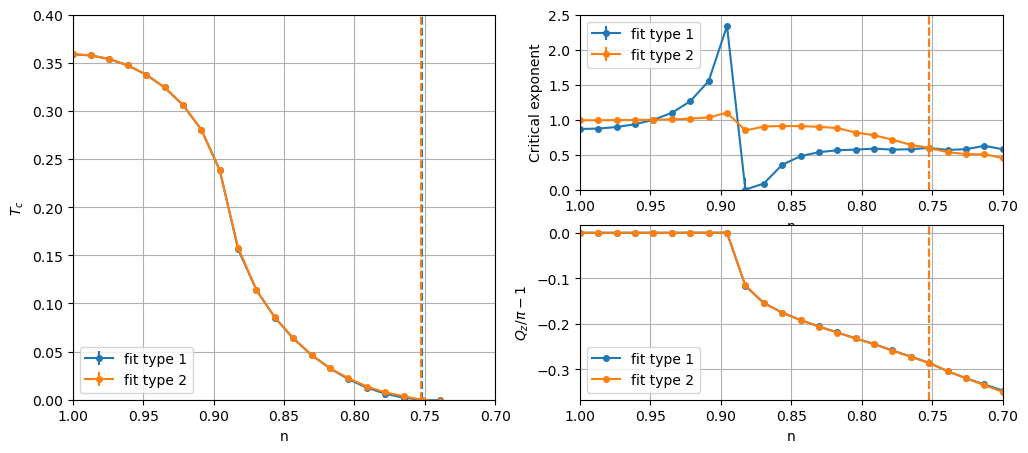

In [15]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.7, 1)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_z/\pi-1$')

results = HDFread_list(f'{save_dir}/nTdiag_U3', ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
n_fits = len(results['Xc'][0])

for i in range(n_fits):
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[i][-1]-1 for Q in results['Qc']]
    Xc = [x[i] for x in results['Xc']]
    Xc_err = [x[i] for x in results['Xc_err']]
    gamma = [x[i] for x in results['gamma']]
    gamma_err = [x[i] for x in results['gamma_err']]
    mu_c = [x[i] for x in results['mu_c']]
    print(mu_c)

    ax[0].errorbar(n_list, Xc, Xc_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    ax[1].errorbar(n_list, gamma, gamma_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"fit type {i+1}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., Xc, n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

In [2]:
U = 3
n_list = np.linspace(0.73, 0.91, 24)
T_list = np.linspace(0., 0.05, 15)

nk = 80
niw = 256
tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-20 01:30:32.518591
Starting serial run at: 2026-05-20 01:30:32.543495
Starting serial run at: 2026-05-20 01:30:32.617177
Starting serial run at: 2026-05-20 01:30:32.639892
Starting serial run at: 2026-05-20 01:30:32.712480


Starting serial run at: 2026-05-20 01:30:32.851810
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 25.2min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 27.0min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 76.4min
/home/ctort/miniconda3/envs/triqs/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Starting serial run at: 2026-05-20 02:46:55.984570


Starting serial run at: 2026-05-20 02:48:04.744237


...

Starting serial run at: 2026-05-20 06:19:37.178436


Starting serial run at: 2026-05-20 06:21:03.534424
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 39.1min


Starting serial run at: 2026-05-20 06:23:06.148863


Starting serial run at: 2026-05-20 06:23:09.357922
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 106.5min


Starting serial run at: 2026-05-20 07:30:30.412440
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 112.3min remaining: 56.2min
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 143.2min remaining: 37.7min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 149.3min remaining: 13.6min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 151.8min finished


24 [0.73, 0.7378260869565217, 0.7456521739130435, 0.7534782608695652, 0.7613043478260869, 0.7691304347826087, 0.7769565217391304, 0.7847826086956522, 0.792608695652174, 0.8004347826086957, 0.8082608695652174, 0.8160869565217391, 0.8239130434782609, 0.8317391304347826, 0.8395652173913044, 0.8473913043478261, 0.8552173913043478, 0.8630434782608696, 0.8708695652173913, 0.8786956521739131, 0.8865217391304347, 0.8943478260869566, 0.9021739130434783, 0.91]
23 [0.73, 0.7378260869565217, 0.7456521739130435, 0.7534782608695652, 0.7613043478260869, 0.7691304347826087, 0.7769565217391304, 0.7847826086956522, 0.792608695652174, 0.8004347826086957, 0.8082608695652174, 0.8160869565217391, 0.8239130434782609, 0.8317391304347826, 0.8395652173913044, 0.8473913043478261, 0.8552173913043478, 0.8630434782608696, 0.8708695652173913, 0.8786956521739131, 0.8943478260869566, 0.9021739130434783, 0.91]
24 [0.73, 0.7378260869565217, 0.7456521739130435, 0.7534782608695652, 0.7613043478260869, 0.7691304347826087, 

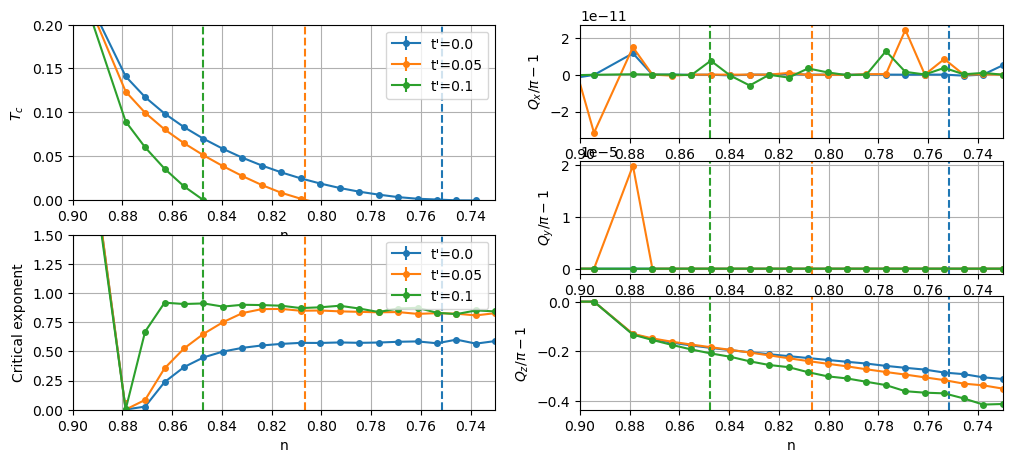

In [11]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.73, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]
    print(len(n_list), n_list)
    n_list.pop(-4)
    print(len(n_list), n_list)
    results['Xc'].pop(-4)
    results['Xc_err'].pop(-4)
    results['gamma'].pop(-4)
    results['gamma_err'].pop(-4)
    results['mu_c'].pop(-4)

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        Qj[j].pop(-4)
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(0., results['mu_c'], n_list)
    #print(n_crit2, tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [4]:
U = 3
n_list = np.linspace(0.87, 0.91, 18)
T_list = np.linspace(0., 0.2, 20)

nk = 80
niw = 256
tp_list = [0.15, 0.2, 0.25]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 2} for par_dict in par_list]
    sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-20 08:15:45.851015
Starting serial run at: 2026-05-20 08:15:45.861739
Starting serial run at: 2026-05-20 08:15:45.870175
Starting serial run at: 2026-05-20 08:15:46.011080


Starting serial run at: 2026-05-20 08:15:46.155436
Starting serial run at: 2026-05-20 08:15:46.177218
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 42.0min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 43.5min
[Parallel(n_jobs=6)]: Done   9 out of  18 | elapsed: 78.2min remaining: 78.2min
[Parallel(n_jobs=6)]: Done  11 out of  18 | elapsed: 80.5min remaining: 51.2min
[Parallel(n_jobs=6)]: Done  13 out of  18 | elapsed: 115.2min remaining: 44.3min
[Parallel(n_jobs=6)]: Done  15 out of  18 | elapsed: 116.6min remaining: 23.3min
[Parallel(n_jobs=6)]: Done  18 out of  18 | elapsed: 119.0min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-20 10:14:47.505070
Starting serial run at: 2026-05-20 10:14:47.514289
Starting serial run at: 2026-05-20 10:14:47.551307
Starting serial run at: 2026-05-20 10:14:47.630188
Starting serial run at: 2026-05-20 10:14:47.636678
Starting serial run at: 2026-05-20 10:14:47.667825


KeyboardInterrupt: 

0.8956605697649895 0.15 [-0.08639099515563704, -0.0779731739738237, -0.06963136590249079, -0.06128699981038275, -0.05282213024515146, -0.04429039497893816, -0.03590796811390671, -0.024299028534145287, -0.022053973167740458, -0.014689346885081273, -0.007053356288263485, 0.0007340214851178149, 0.008586929507861102, 0.016478854918051972, 0.024398719517413126, 0.032338671107127216, 0.04029563215223876, 0.04824785959383307]
0.8597724171038438 0.2 [-0.03591634467455139, 0.00818698529128608, 0.060742089186450784, 0.0926929204048223, 0.13224047657390484, 0.17198129120045863]
0.8619928557918269 0.25 [-223.93295114421605, 0.13339805360379386, 0.1756663944720431, 0.22497331863585346, 0.25785979329618447, 0.2964685131439503]


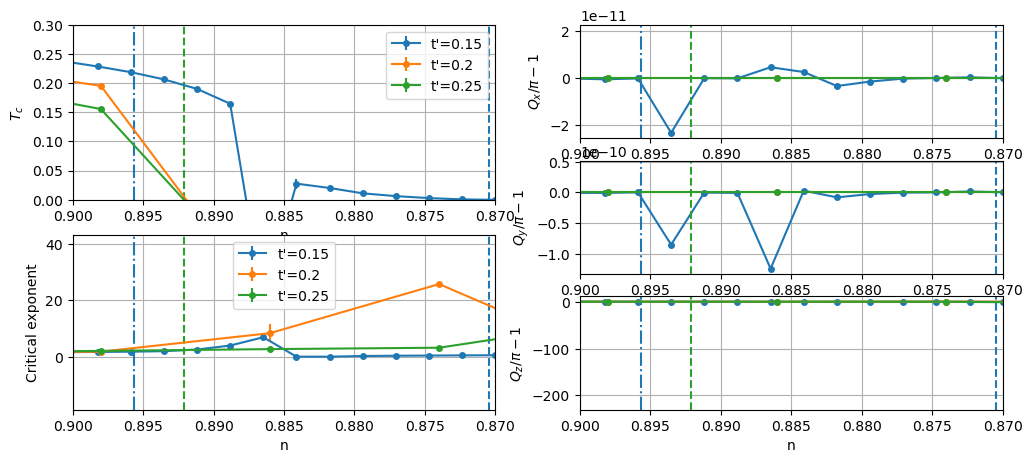

In [5]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.87, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.3)
#ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0.15, 0.2, 0.25]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(0., results['mu_c'], n_list)
    print(n_crit2, tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [25]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 50
niw = 128
tp_list = [-0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': False} for #par_dict in par_list]
    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
                   'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-05-15 16:59:33.249822
Starting serial run at: 2026-05-15 16:59:33.249822
Starting serial run at: 2026-05-15 16:59:33.265697
Starting serial run at: 2026-05-15 16:59:33.267767


Starting serial run at: 2026-05-15 16:59:33.322594
Starting serial run at: 2026-05-15 16:59:33.332669
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    4.5s
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:    4.9s remaining:   14.7s
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:    5.8s remaining:    8.1s
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:    8.2s remaining:    5.9s
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:    8.9s remaining:    3.0s
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:   10.4s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    4.0s
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:    4.2s remaining:   12.7s
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:    4.5s remaining:    6.3s
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:    7.4s remaining:    5.3s
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:    8.0s remaining:

0.0 [-0.9481132555863129, -0.8841523777466039, -0.8335072933733159, -0.771012558120248, -0.7175195917152137, -0.6589364963136722, -0.6019023651700948, -0.5445839862467969, -0.4872677574266172, -0.429920945564759, -0.3725154341263059, -0.3152494760228582]
-0.05 [-1.0671951331469793, -1.029137892163836, -0.9184250332785706, -0.8794443103899608, -0.8407183438738781, -0.7861699130581287, -0.7200855528433826, -0.6642551789063457, -0.6078556789003859, -0.5507410611669328, -0.492650789444007, -0.4347943253648767]
-0.1 [-1.1697270091312866, -1.0662378413502094, -1.1038100635492265, -1.0343212995166788, -0.9427828311297325, -0.8879611606798635, -0.8483402924082443, -0.7843265579111319, -0.7272583568513871, -0.6703640148036035, -0.6116662256370465, -0.5534357809834232]
-0.15 [-1.4600158670602825, -1.2787816457031045, -1.1673537588654028, -1.1050007319630677, -1.0946337174266918, -1.0074793012681837, -0.9505731021415931, -0.8966657875207377, -0.8454894209698526, -0.788658340006893, -0.72932355633

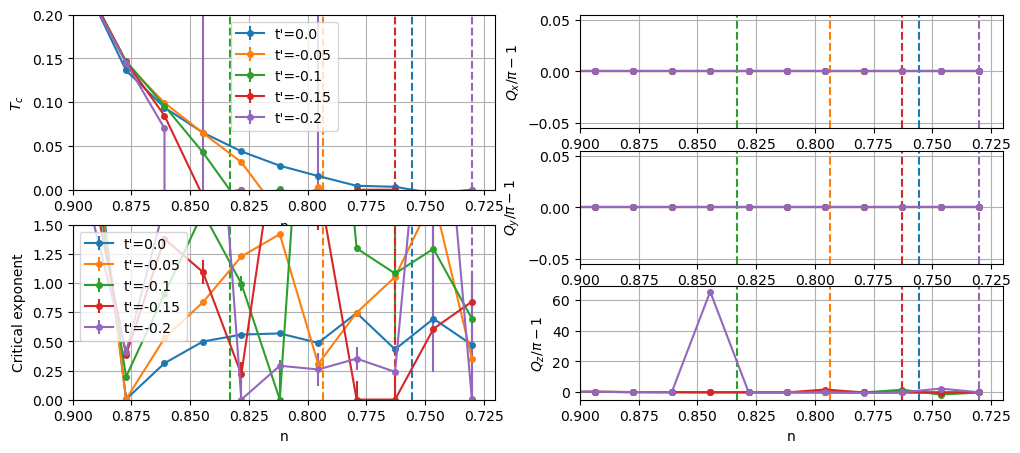

In [30]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., -0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(-tp, results['mu_c'], n_list)
    print(tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/negtp.png', dpi=100)
plt.show()

In [ ]:
save_dir = f'data/{dim}d/rpa_ba'

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 100
niw = 128
Gamma_list = [0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma, 'niw': niw, 'niw_extr': True, 'refine': False} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma,
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-05-15 05:15:51.299732
Starting serial run at: 2026-05-15 05:15:51.299745


Starting serial run at: 2026-05-15 05:15:51.322664
Starting serial run at: 2026-05-15 05:15:51.326467
Starting serial run at: 2026-05-15 05:15:51.376726
Starting serial run at: 2026-05-15 05:15:51.379596
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  5.0min remaining: 14.9min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.8min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:25:47.708346
Starting serial run at: 2026-05-15 05:25:47.708349
Starting serial run at: 2026-05-15 05:25:47.708813
Starting serial run at: 2026-05-15 05:25:47.711708
Starting serial run at: 2026-05-15 05:25:47.733452
Starting serial run at: 2026-05-15 05:25:47.733728
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  4.9min remaining: 14.8min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.7min remaining:  6.9min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:35:42.790420
Starting serial run at: 2026-05-15 05:35:42.809774
Starting serial run at: 2026-05-15 05:35:42.833245
Starting serial run at: 2026-05-15 05:35:42.836123
Starting serial run at: 2026-05-15 05:35:42.863344
Starting serial run at: 2026-05-15 05:35:42.868472
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.8min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  5.0min remaining: 14.9min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.7min remaining:  6.9min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:45:37.728594
Starting serial run at: 2026-05-15 05:45:37.728595
Starting serial run at: 2026-05-15 05:45:37.729138
Starting serial run at: 2026-05-15 05:45:37.729590
Starting serial run at: 2026-05-15 05:45:37.733205
Starting serial run at: 2026-05-15 05:45:37.733732
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  4.9min remaining: 14.8min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.8min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished


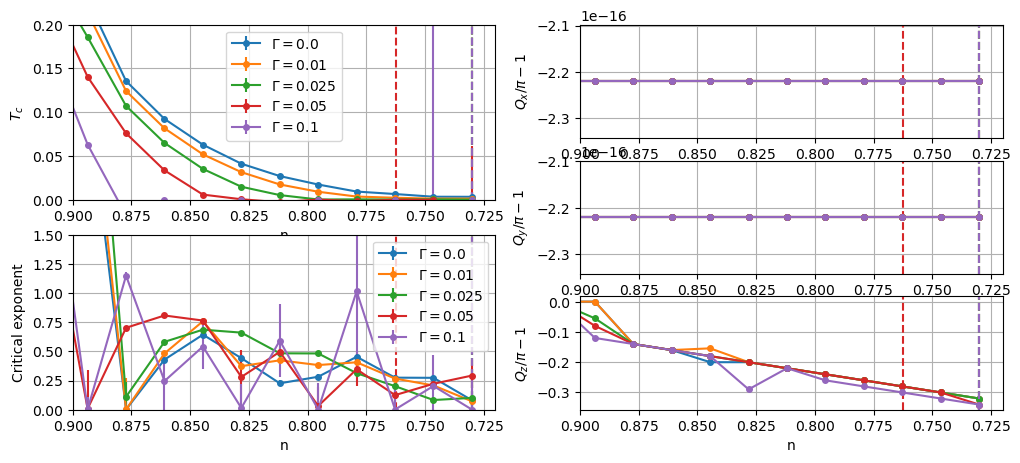

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

Gamma_list = [0., 0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [3]:
import tracemalloc

tracemalloc.start()
lattice = LATTICE()
nk = 300
lattice.get_k_mesh(nk, ibz=True)
lattice.get_e_k()
print(len(lattice.e_k),'/',nk**3, lattice.e_k)
print(lattice.ibz_w_k.sum())

current, peak = tracemalloc.get_traced_memory()
print(f"peak during fourier: {peak / 1e6:.1f} MB")
tracemalloc.stop()

585276 / 27000000 [-6.         -5.99956137 -5.99824566 ...  5.99912273  5.99956137
  6.        ]
27000000
peak during fourier: 758.7 MB
